# <center> <img src="figs/LogoUFSCar.jpg" alt="Logo UFSCar" width="110" align="left"/>  <br/> <center>Universidade Federal de São Carlos (UFSCar)<br/><font size="4"> Departamento de Computação, campus Sorocaba</center></font>
</p>

<font size="4"><center><b>Disciplina: Processamento de Linguagem Natural</b></center></font>

<font size="3"><center>Prof. Dr. Tiago A. Almeida</center></font>

## <center>Projeto Final - Classificação Automática de Documentos Jurídicos</center>

**Nome**: Anderson Cristiano Sassaki Gonçalves

**RA**: 821675

**Nome**: Lorenzo Grippo Chiachio

**RA**: 823917


---
## Visão geral da solução

Este notebook implementa uma solução completa para a classificação de documentos jurídicos da base VICTOR/STF. A tarefa é classificar cada texto extraído do `train.csv` em uma das categorias do projeto e gerar uma submissão para o `test.csv`, respeitando uma restrição importante: durante o desenvolvimento, usamos apenas os campos disponíveis nos arquivos CSV (`Id`, `Body` e `Category` no treino; `Id` e `Body` no teste).

A organização foi revista para atender a dois objetivos. O primeiro é didático: cada seção explica o que está sendo feito, por que aquela etapa é necessária e como o resultado influencia a etapa seguinte. O segundo é operacional: etapas caras, como pré-processamento, validação cruzada, geração de probabilidades e fine-tuning, salvam artefatos em disco para que execuções futuras possam reaproveitar o que já foi calculado.

O notebook está organizado em oito seções principais:

1. **Carregamento e contrato dos dados**: leitura dos CSVs e verificação do formato esperado.
2. **Análise exploratória**: distribuição das classes, tamanho dos textos e vocabulário jurídico.
3. **Pré-processamento e cache**: limpeza textual com salvamento dos CSVs processados.
4. **Tarefas básicas de PLN e sinais de domínio**: features jurídicas e linguísticas auxiliares.
5. **Representações e modelos clássicos**: baselines e modelos TF-IDF fortes.
6. **Validação robusta e ensemble CSV-only**: OOF, auditoria, prior de duplicatas e Viterbi por `Id`.
7. **Modelos densos e Transformers**: embeddings por chunks e Legal-BERTimbau com truncamento `head+tail`.
8. **Comparação final e submissão**: escolha justificada do melhor caminho e treino final com todos os dados disponíveis.


Ao final, há ainda uma seção extra chamada **Best effort RTX 5000 32 GB**. Ela não substitui as oito seções exigidas; é um experimento isolado, pensado para uma GPU mais forte, com Legal-BERTimbau Large, treino final em todos os dados disponíveis e pós-processamento sequencial.

Uma observação importante: validação e submissão são etapas diferentes. As divisões de validação existem para escolher hiperparâmetros, modelos e pesos de ensemble sem olhar o teste. Depois que a escolha é feita, o modelo final é treinado novamente usando todos os dados rotulados disponíveis antes de gerar a submissão final.


---
## Dependências e estratégia de dispositivo

A célula abaixo verifica se as bibliotecas necessárias estão disponíveis no ambiente Python do notebook. As dependências básicas cobrem análise, visualização e modelos clássicos. As dependências avançadas são usadas para embeddings e Transformers.

O código posterior detecta automaticamente o dispositivo disponível. Em uma GPU NVIDIA, usa `cuda` e precisão mista quando possível. Em Apple Silicon, usa `mps`. Em máquinas sem acelerador, mantém o caminho em `cpu`. O objetivo é que o notebook rode de forma independente da máquina; o que muda é apenas o tempo de execução e o tamanho de batch recomendado.


In [1]:
import importlib.util
import subprocess
import sys

BASE_MODULES = ["pandas", "numpy", "sklearn", "matplotlib", "seaborn", "joblib"]
ADVANCED_MODULES = ["torch", "transformers", "datasets", "sentence_transformers", "accelerate"]

missing_base = [pkg for pkg in BASE_MODULES if importlib.util.find_spec(pkg) is None]
if missing_base:
    print("Instalando dependências base ausentes:", missing_base)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"])
else:
    print("Dependências base já disponíveis.")

missing_advanced = [pkg for pkg in ADVANCED_MODULES if importlib.util.find_spec(pkg) is None]
if missing_advanced:
    print("Instalando dependências avançadas ausentes:", missing_advanced)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements-advanced.txt"])
else:
    print("Dependências avançadas já disponíveis.")

importlib.invalidate_caches()
print("Ambiente pronto para executar o pipeline completo.")


Dependências base já disponíveis.
Dependências avançadas já disponíveis.
Ambiente pronto para executar o pipeline completo.


In [2]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload


---
## Configuração global e módulos do projeto

Esta célula centraliza caminhos, flags de cache e imports. Em geral, ela deve ser executada uma vez no início da sessão. As seções mais caras também têm proteções para recarregar seus próprios artefatos quando possível, mas manter esta célula como ponto de entrada deixa a execução mais simples e previsível.

As flags abaixo controlam quando recalcular uma etapa. Por padrão, todas ficam em `False`: se um arquivo de cache já existir, ele será reaproveitado. Para forçar a reconstrução de uma etapa específica, basta alterar a flag correspondente para `True` e executar novamente a seção desejada.


In [3]:
from pathlib import Path
import json
import os
import shutil
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-cache")

import numpy as np
import pandas as pd

PROJECT_DIR = Path.cwd().resolve()
if (PROJECT_DIR / "template-implementacao" / "scripts").exists():
    PROJECT_DIR = PROJECT_DIR / "template-implementacao"
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
MODEL_DIR = PROJECT_DIR / "models"
CACHE_DIR = OUTPUT_DIR / "cache"
REPORT_DIR = OUTPUT_DIR / "reports"

for directory in [OUTPUT_DIR, MODEL_DIR, CACHE_DIR, REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

FORCE_REBUILD_PREPROCESS = False
FORCE_RETRAIN_CLASSICAL = False
FORCE_REBUILD_OOF = False
FORCE_REBUILD_AUDIT = False
FORCE_REBUILD_EMBEDDINGS = False
FORCE_RETRAIN_TRANSFORMER = False
FORCE_RETRAIN_FINAL = False

from scripts.analise_exploratoria import (
    add_text_statistics,
    duplicate_text_report,
    get_top_terms,
    load_competition_data,
    plot_class_distribution,
    plot_text_length_distribution,
    plot_top_terms,
    summarize_dataset,
    text_length_percentiles,
    validate_schema,
    split_labeled_unlabeled,
)
from scripts.analise_resultados import (
    classification_report_frame,
    plot_confusion_matrix,
    plot_metric_comparison,
    rank_results,
    save_experiment_report,
    save_results_table,
)
from scripts.experimentos import (
    ExperimentConfig,
    auto_runtime_profile,
    average_probabilities,
    build_chunked_sentence_embedding_matrix,
    build_embedding_classifier_zoo,
    build_fast_sparse_model_zoo,
    build_sparse_model_zoo,
    build_training_set_with_pseudo_labels,
    combine_with_duplicate_prior,
    cross_validate_best_models,
    detect_label_issues_with_cv,
    duplicate_prior_probabilities,
    estimate_transition_matrix,
    evaluate_embedding_classifier,
    evaluate_model_zoo,
    fine_tune_transformer_classifier,
    fit_embedding_classifier_on_full_train,
    fit_model_on_full_train,
    generate_embedding_submission,
    generate_submission,
    generate_transformer_submission,
    load_model,
    load_transformer_trainer,
    make_oof_duplicate_prior_probabilities,
    make_oof_probabilities,
    optimize_duplicate_lambda,
    optimize_ensemble_weights,
    optimize_transition_lambda_oof,
    pseudo_label_unlabeled_samples,
    save_model,
    select_best_model,
    sequential_signal_report,
    transductive_viterbi_submission,
    transformer_candidate_models,
)
from scripts.notebook_support import cached_preprocessed_data, read_cached_csv, resolve_project_dir, write_cached_csv
from scripts.preprocessamento import (
    CLASS_NAMES,
    TextPreprocessConfig,
    add_clean_body_column,
    add_clean_text_column,
    extract_basic_nlp_features,
    extract_legal_signal_features,
)

pd.set_option("display.max_colwidth", 180)

preprocess_config = TextPreprocessConfig(
    lowercase=True,
    strip_accents=True,
    normalize_legal_refs=True,
    remove_urls_emails=True,
    remove_stopwords=False,
    min_token_len=2,
    keep_digits=False,
)

experiment_config = ExperimentConfig(
    text_col="Body_clean",
    target_col="Category",
    id_col="Id",
    random_state=42,
    validation_size=0.2,
    cv_folds=5,
    scoring="f1_macro",
    output_dir=str(OUTPUT_DIR),
)

runtime_profile = auto_runtime_profile(prefer_transformer=True)

def choose_best_probabilistic_model(ranked_df, models):
    """Escolhe o melhor modelo ranqueado que produz probabilidades confiáveis."""
    for name in ranked_df["model"].tolist():
        estimator = models.get(name)
        if estimator is not None and hasattr(estimator, "predict_proba"):
            return name
    return ranked_df.iloc[0]["model"]

print("Diretório do projeto:", PROJECT_DIR)
print("Diretório de cache:", CACHE_DIR)
print("Dispositivo preferencial:", runtime_profile["device"])
print("Transformer recomendado:", runtime_profile["recommended_transformer"])


Diretório do projeto: /Users/andersongoncalves/Documents/PLN-Final/template-implementacao
Diretório de cache: /Users/andersongoncalves/Documents/PLN-Final/template-implementacao/outputs/cache
Dispositivo preferencial: mps
Transformer recomendado: rufimelo/Legal-BERTimbau-sts-base-ma-v2


---
## 1. Carregamento e contrato dos dados

Antes de qualquer modelagem, precisamos garantir que os arquivos possuem o formato esperado. Esta etapa lê `train.csv`, `test.csv` e, quando disponível, `sample_submission.csv`. O carregador procura primeiro em `data/`, mas também aceita os CSVs na raiz do projeto, o que facilita alternar entre execução local, Kaggle e servidor remoto.

O `train.csv` deve conter `Id`, `Body` e `Category`; o `test.csv` deve conter `Id` e `Body`. Também separamos as linhas com rótulos válidos das linhas com `Category = -1`. Essas linhas sem rótulo não entram diretamente na validação supervisionada, mas podem ser reaproveitadas depois com pseudo-rotulagem conservadora.


In [4]:
train_df, test_df, sample_df = load_competition_data(DATA_DIR)
schema_report = validate_schema(train_df, test_df, sample_df)
train_labeled, train_unlabeled = split_labeled_unlabeled(train_df)

schema_frame = pd.DataFrame([
    {
        "train_linhas": len(train_df),
        "test_linhas": len(test_df),
        "rotuladas_validas": len(train_labeled),
        "sem_rotulo_ou_invalidas": len(train_unlabeled),
        "train_ids_duplicados": schema_report["duplicated_train_ids"],
        "test_ids_duplicados": schema_report["duplicated_test_ids"],
    }
])
display(schema_frame)

display(train_labeled.head(3))
display(test_df.head(3))
if sample_df is not None:
    display(sample_df.head(3))


,train_linhas,test_linhas,rotuladas_validas,sem_rotulo_ou_invalidas,train_ids_duplicados,test_ids_duplicados
0,22680,2521,20412,2268,0,0


,Id,Body,Category
0,12980,"{""conclusÃ£o diante exposto recorrente espera confia que recurso ora arrazoado interposto com fulcro ARTIGO_102 iii constituiÃ§Ã£o federal serÃ¡ admitido conhecido provido fim ...",3
1,9775,"{""ARTIGO_55 gecen a gacen serÃ£o devidas aos titulares dos empregos cargos pÃºblicos que tratam ARTIGO_53 desta lei que carÃ¡ter permanente realizarem atividades combate contro...",3
2,16061,"{""seguir desacerto decisÃ£o que negou seguimento recurso extraordinÃ¡rio equÃ­voco decisÃ£o discutida constitucionalidade prazo mÃ­nimo anos para que impedimento possa ser cons...",1


,Id,Body
0,9213,"{""um regime democrática direito qual seja da separação dos poderes recurso inominado parte autora improvido sem condenação ônus sucumbenciais por força concessão benefício just..."
1,17427,"{""controvérsia fato que requerente participante rpps junto prefeitura municipal roca sales desde que valores atinentes aposentadorias rurais não são essenciais para sua sobrevi..."
2,4753,"{""advocacia geral união procuradoria união paraíba excelentíssimo senhor juiz federal presidente turma recursal dos juizados especiais paraíba união por sua advogada união fina..."


,Id,Category
0,7271,3
1,861,4
2,5391,0


---
## 2. Análise exploratória

A análise exploratória orienta as escolhas de modelagem. Neste problema, três perguntas são especialmente importantes:

1. As classes estão desbalanceadas?
2. Os textos cabem em janelas tradicionais de 512 tokens ou exigem estratégias para documentos longos?
3. Existem termos jurídicos claramente associados a algumas classes?

A primeira pergunta define as métricas: `accuracy` sozinha é insuficiente em uma base desbalanceada, então usamos `f1_macro` e `f1_weighted`. A segunda pergunta influencia a escolha entre BERT tradicional, `head+tail` e modelos de contexto longo. A terceira ajuda a explicar por que TF-IDF de palavras e caracteres ainda é uma baseline forte para documentos jurídicos.


,Category,count,percent
3,0,665,3.257888
1,1,3529,17.288850
4,2,439,2.150696
0,3,12876,63.080541
2,4,2903,14.222026


,missing
Id,0
Body,0
Category,0


n_chars                                                           \
            count         mean         std    min      25%     50%     75%   
Category                                                                     
0           665.0  2011.908271  907.395586  155.0  1292.00  2119.0  2615.0   
1          3529.0  1578.096345  735.338974    4.0  1086.00  1456.0  2016.0   
2           439.0  1195.735763  852.372715  113.0   443.00  1154.0  1508.5   
3         12876.0  1746.595216  704.201052   33.0  1360.75  1712.0  2124.0   
4          2903.0  2046.951085  771.020978   94.0  1602.00  1931.0  2640.0   

                  n_words              ...               unique_word_ratio  \
             max    count        mean  ...    75%    max             count   
Category                               ...                                   
0         4798.0    665.0  251.539850  ...  326.0  576.0             665.0   
1         5702.0   3529.0  195.200057  ...  248.0  685.0            3529.0   
2         6867.0    439.0  149.036446  ...  186.5  844.0             439.0   
3         5923.0  12876.0  213.882883  ...  260.0  781.0           12876.0   
4         6448.0   2903.0  254.391319  ...  324.0  837.0            2903.0   

                                                                           
              mean       std       min       25%       50%       75%  max  
Category                                                                   
0         0.773313  0.095599  0.493671  0.719008  0.772727  0.827206  1.0  
1         0.765190  0.088360  0.287037  0.708812  0.768293  0.821138  1.0  
2         0.771077  0.125442  0.496445  0.655629  0.750000  0.867839  1.0  
3         0.748295  0.080344  0.311450  0.700472  0.748503  0.796667  1.0  
4         0.712588  0.096364  0.322464  0.648438  0.698551  0.768298  1.0  

[5 rows x 24 columns]

Matplotlib is building the font cache; this may take a moment.


(<Figure size 1400x400 with 2 Axes>,
 array([<Axes: title={'center': 'Distribuicao de n_words'}, xlabel='n_words', ylabel='Count'>,
        <Axes: title={'center': 'n_words por categoria'}, xlabel='Categoria', ylabel='n_words'>],
       dtype=object))

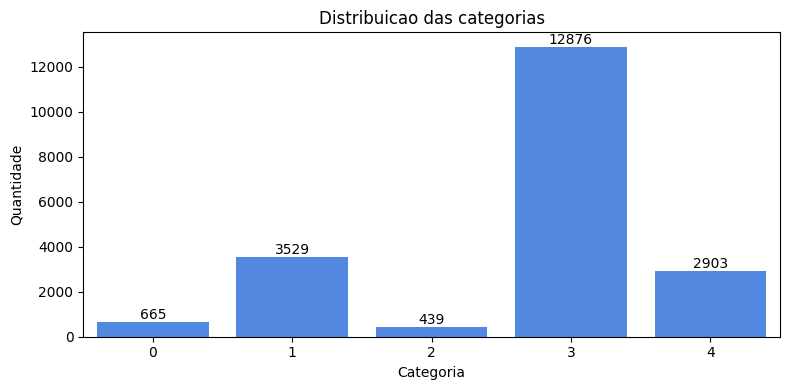

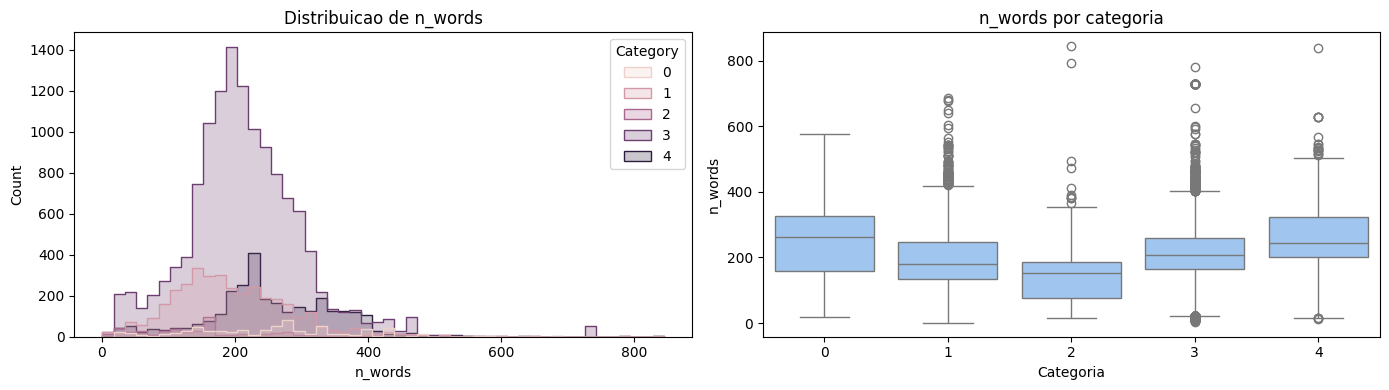

In [5]:
eda = summarize_dataset(train_labeled)
train_stats = eda["data_with_stats"]

display(eda["class_distribution"])
display(eda["missing_summary"])
display(eda["length_summary"])

plot_class_distribution(eda["class_distribution"])
plot_text_length_distribution(train_stats, metric="n_words")


Termos mais relevantes salvos em: /Users/andersongoncalves/Documents/PLN-Final/template-implementacao/outputs/cache/top_terms_raw.csv


,Category,rank,term,mean_tfidf
0,0,1,que,0.036902
1,0,2,dos,0.031524
2,0,3,nã,0.029471
3,0,4,por,0.026011
4,0,5,para,0.024199
5,0,6,nos,0.023581
6,0,7,federal,0.023564
7,0,8,recurso,0.022596
8,0,9,com,0.022066
9,0,10,relator,0.021224


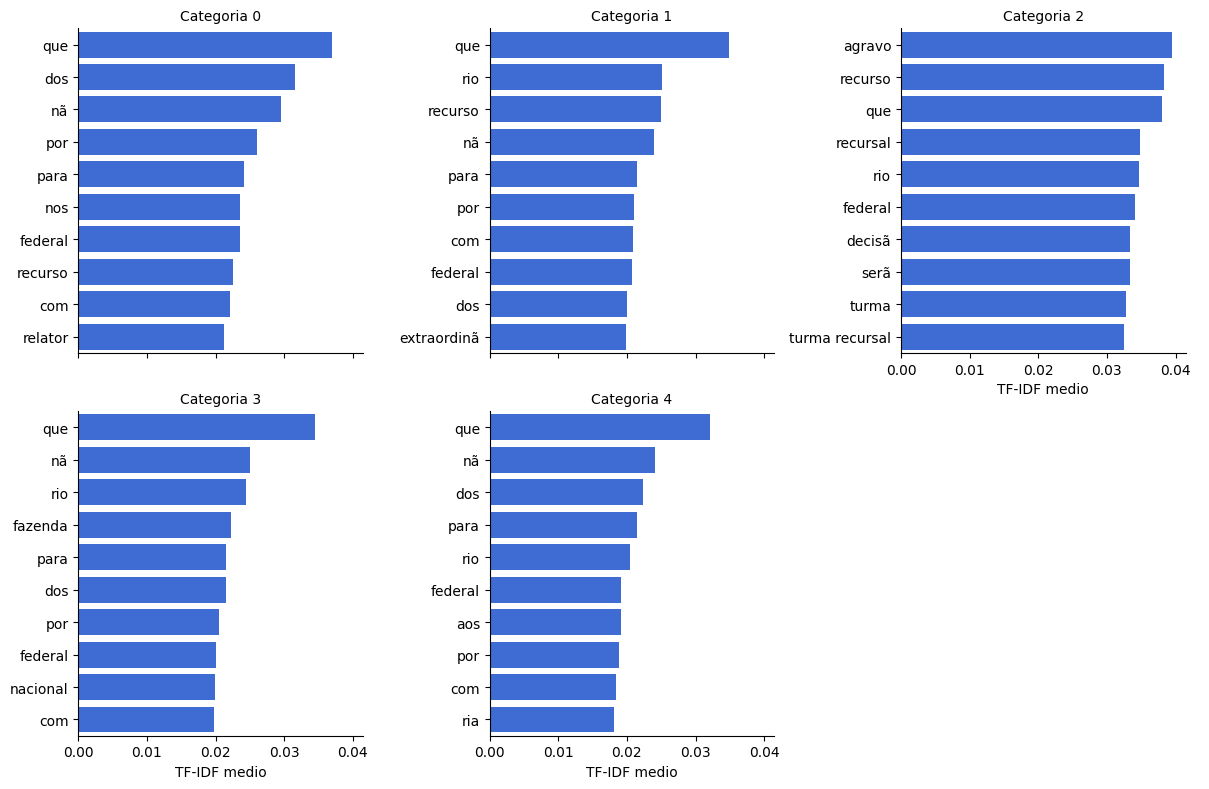

In [6]:
top_terms_path = CACHE_DIR / "top_terms_raw.csv"
if top_terms_path.exists() and not FORCE_REBUILD_PREPROCESS:
    top_terms = pd.read_csv(top_terms_path)
    print("Termos mais relevantes carregados do cache:", top_terms_path)
else:
    top_terms = get_top_terms(train_labeled, n_terms=12)
    top_terms.to_csv(top_terms_path, index=False)
    print("Termos mais relevantes salvos em:", top_terms_path)

display(top_terms.head(30))
plot_top_terms(top_terms, n_terms=10)


A leitura dos termos por classe deve ser feita com cautela. Termos como `recurso`, `agravo`, `acordao`, `sentenca`, `despacho`, `turma`, `relator` e expressões processuais carregam sinal jurídico forte, mas também podem aparecer em mais de uma categoria. Isso explica por que modelos lineares com n-gramas costumam ser competitivos: eles capturam padrões lexicais diretos e, ao mesmo tempo, são robustos a textos curtos ou ruidosos.


---
## 3. Pré-processamento e cache

O pré-processamento tem duas responsabilidades. A primeira é corrigir problemas do texto extraído, como mojibake (`conclusÃ£o`), quebras de linha artificiais e ruídos de OCR. A segunda é criar uma representação limpa e estável (`Body_clean`) para que todas as etapas posteriores trabalhem sobre a mesma entrada.

Como esta etapa é executada por todos os experimentos, ela agora grava três arquivos em `outputs/cache/`:

- `train_clean.csv`: treino rotulado com `Body_clean`;
- `test_clean.csv`: teste com `Body_clean`;
- `train_unlabeled_clean.csv`: linhas sem rótulo válido, também pré-processadas.

Se esses arquivos já existirem e a configuração de limpeza não tiver mudado, eles são carregados diretamente. Isso evita recalcular a limpeza toda vez que o notebook é reaberto.


In [7]:
cache_bundle = cached_preprocessed_data(
    project_dir=PROJECT_DIR,
    data_dir=DATA_DIR,
    output_dir=OUTPUT_DIR,
    config=preprocess_config,
    force=FORCE_REBUILD_PREPROCESS,
)

train_clean = cache_bundle["train_clean"]
test_clean = cache_bundle["test_clean"]
train_unlabeled_clean = cache_bundle["train_unlabeled_clean"]

print("Status do pré-processamento:", cache_bundle["cache_status"])
print("Arquivos de cache em:", CACHE_DIR)
display(train_clean[["Id", "Category", "Body", "Body_clean"]].head(3))


Status do pré-processamento: loaded
Arquivos de cache em: /Users/andersongoncalves/Documents/PLN-Final/template-implementacao/outputs/cache


,Id,Category,Body,Body_clean
0,12980,3,"{""conclusÃ£o diante exposto recorrente espera confia que recurso ora arrazoado interposto com fulcro ARTIGO_102 iii constituiÃ§Ã£o federal serÃ¡ admitido conhecido provido fim ...",conclusao diante exposto recorrente espera confia que recurso ora arrazoado interposto com fulcro artigo_ iii constituicao federal sera admitido conhecido provido fim que seja ...
1,9775,3,"{""ARTIGO_55 gecen a gacen serÃ£o devidas aos titulares dos empregos cargos pÃºblicos que tratam ARTIGO_53 desta lei que carÃ¡ter permanente realizarem atividades combate contro...",artigo_ gecen gacen serao devidas aos titulares dos empregos cargos publicos que tratam artigo_ desta lei que carater permanente realizarem atividades combate controle endemias...
2,16061,1,"{""seguir desacerto decisÃ£o que negou seguimento recurso extraordinÃ¡rio equÃ­voco decisÃ£o discutida constitucionalidade prazo mÃ­nimo anos para que impedimento possa ser cons...",seguir desacerto decisao que negou seguimento recurso extraordinario equivoco decisao discutida constitucionalidade prazo minimo anos para que impedimento possa ser considerado...


,split,mean,median,max,p50,p90,p95,p99
0,train,213.199490,206.0,827.0,206.0,323.0,375.0,462.0
1,test,215.258628,207.0,730.0,207.0,327.0,381.0,464.8


,n_train_rows,n_unique_texts,n_duplicate_rows,n_duplicate_texts,n_conflicting_texts,n_same_label_duplicate_texts,n_test_rows_seen_in_train
0,20412,10544,9868,2268,25,2243,1459


Textos duplicados com rótulos conflitantes:


,Body_clean,n_labels
0,anda natacha estreito rosa pagina,2
1,arcio louzada carpena pagina,2
2,artigo_ respeitada inconstitucionalidade por arrastamento declarada pelo stf acerca tema vejamos esclarecimentos extraidos site supremo tribunal federal site quais adiro julgam...,2
3,correcao monetaria condenacoes contra fazenda publica quanto regime atualizacao monetaria das condenacoes impostas fazenda publica questao reveste de sutilezas formais explico ...,2
4,diante disso acao comento visa assegurar aos servidores que aposentaram anteriormente ec virtude principio isonomia paridade recebimento pontuacao garantida pela lei_ eis que n...,2
5,direito dos aposentados pensionistas paridade com servidores ativos recebimento remuneracao beneficios esta expressamente previsto constituicao federal que pese haver alteracoe...,2
6,fazenda divida natureza tributaria incidem juros pela taxa selic como compensacao pela mora devendo esse mesmo indice por forca principio equidade ser aplicado quando for ela d...,2
7,fixada pelo quer seja do artigo_ cpc devem levar consideracao grau zelo profissional local prestacao servico natureza importancia causa trabalho realizado pelo advogado tempo d...,2
8,fls este documento copia original assinado digitalmente por marco aurelio funck savoia tribunal justica estado sao paulo protocolado sob numero para acessar autos processuais a...,2
9,plenario iniciou julgamento recurso extraordinario que discute cabimento juros mora periodo compreendido entre data conta liquidacao expedicao requisicao pequeno valor rpv mini...,2


Proporção de pares consecutivos por Id com a mesma classe: 0.8933418254862574


,count,mean,std,min,25%,50%,75%,max
0,20411.0,1.234628,0.546037,1.0,1.0,1.0,1.0,8.0


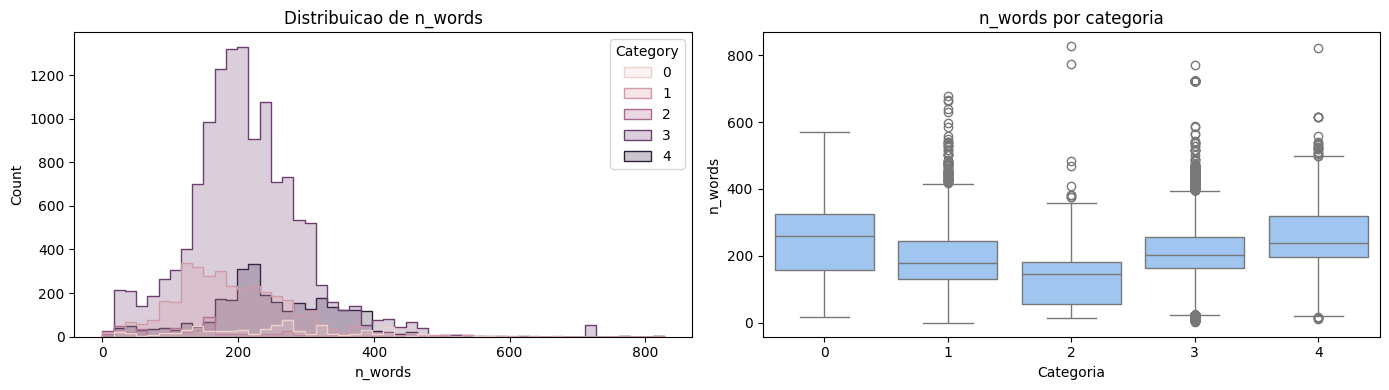

In [8]:
train_clean_stats = add_text_statistics(train_clean, text_col="Body_clean")
length_summary = pd.DataFrame([
    {"split": "train", **text_length_percentiles(train_clean, text_col="Body_clean")},
    {"split": "test", **text_length_percentiles(test_clean, text_col="Body_clean")},
])
display(length_summary)
plot_text_length_distribution(train_clean_stats, metric="n_words")

duplicate_report = duplicate_text_report(train_clean, test_clean, text_col="Body_clean")
duplicate_summary = pd.DataFrame([duplicate_report["summary"]])
duplicate_summary.to_csv(REPORT_DIR / "duplicate_summary.csv", index=False)
display(duplicate_summary)

if not duplicate_report["conflicting_texts"].empty:
    print("Textos duplicados com rótulos conflitantes:")
    display(duplicate_report["conflicting_texts"].head(10))

sequence_report = sequential_signal_report(train_clean, config=experiment_config)
print("Proporção de pares consecutivos por Id com a mesma classe:", sequence_report["same_next"])
display(pd.DataFrame([sequence_report["id_diff_describe"]]))


O relatório de duplicatas é importante porque textos idênticos com o mesmo rótulo podem inflar a validação se aparecerem simultaneamente em treino e validação. Textos idênticos com rótulos diferentes indicam um limite real para qualquer modelo que use apenas `Body`. Por isso, o notebook usa `GroupKFold` e priors de duplicata calculados fora da dobra quando avalia esse tipo de sinal.


---
## 4. Tarefas básicas de PLN e sinais de domínio

Além das representações estatísticas e neurais, o projeto pede tarefas básicas de PLN quando elas ajudam a entender o problema. Nesta seção extraímos dois grupos de atributos:

1. **Sinais jurídicos determinísticos**, como presença relativa de expressões associadas a acórdão, ARE, RE, despacho e sentença.
2. **Sinais linguísticos opcionais**, como contagens de PoS e entidades nomeadas via spaCy, quando o modelo de português estiver instalado.

Essas features não substituem TF-IDF nem Transformers. Elas funcionam como uma camada interpretável: ajudam a explicar quais pistas jurídicas estão visíveis no texto e podem ser usadas em análises posteriores de erro.


In [9]:
legal_features_path = CACHE_DIR / "legal_features.csv"
nlp_features_path = CACHE_DIR / "nlp_features.csv"

if legal_features_path.exists() and nlp_features_path.exists() and not FORCE_REBUILD_PREPROCESS:
    legal_features = pd.read_csv(legal_features_path)
    nlp_features = pd.read_csv(nlp_features_path)
    print("Features carregadas do cache.")
else:
    legal_features = extract_legal_signal_features(train_clean, text_col="Body_clean")
    nlp_features = extract_basic_nlp_features(train_clean, text_col="Body")
    legal_features.to_csv(legal_features_path, index=False)
    nlp_features.to_csv(nlp_features_path, index=False)
    print("Features salvas no cache.")

print("Features jurídicas:", legal_features.shape)
display(legal_features.head())
print("Features básicas de PLN/fallback:", nlp_features.shape)
display(nlp_features.head())


Features salvas no cache.
Features jurídicas: (20412, 14)


,feat_word_count,feat_char_count,feat_digit_ratio,feat_upper_ratio,feat_unique_word_ratio,feat_process_ref_count,feat_article_ref_count,feat_date_ref_count,kw_acordao,kw_are,kw_despacho,kw_re,kw_sentenca,kw_ocr_noise
0,56,430,0.0,0.0,0.928571,0,0,0,0.017857,0.000000,0.000000,0.017857,0.000000,0.0
1,136,1009,0.0,0.0,0.720588,0,0,0,0.000000,0.036765,0.007353,0.000000,0.000000,0.0
2,203,1649,0.0,0.0,0.802956,0,0,0,0.000000,0.000000,0.004926,0.009852,0.000000,0.0
3,309,2440,0.0,0.0,0.692557,0,0,2,0.003236,0.000000,0.000000,0.009709,0.000000,0.0
4,458,3465,0.0,0.0,0.655022,0,0,1,0.028384,0.002183,0.006550,0.002183,0.010917,0.0


Features básicas de PLN/fallback: (20412, 14)


,feat_word_count,feat_char_count,feat_digit_ratio,feat_upper_ratio,feat_unique_word_ratio,feat_process_ref_count,feat_article_ref_count,feat_date_ref_count,kw_acordao,kw_are,kw_despacho,kw_re,kw_sentenca,kw_ocr_noise
0,56,430,0.0,0.0,0.928571,0,0,0,0.017857,0.000000,0.000000,0.017857,0.000000,0.0
1,136,1009,0.0,0.0,0.720588,0,0,0,0.000000,0.036765,0.007353,0.000000,0.000000,0.0
2,203,1649,0.0,0.0,0.802956,0,0,0,0.000000,0.000000,0.004926,0.009852,0.000000,0.0
3,309,2440,0.0,0.0,0.692557,0,0,2,0.003236,0.000000,0.000000,0.009709,0.000000,0.0
4,458,3465,0.0,0.0,0.655022,0,0,1,0.028384,0.002183,0.006550,0.002183,0.010917,0.0


---
## 5. Representações textuais e modelos clássicos

Os modelos clássicos são o primeiro bloco de experimentos porque são baratos, interpretáveis e muito fortes para classificação textual. No VICTOR/STF, o texto contém fórmulas jurídicas, siglas, termos processuais e padrões de OCR; por isso usamos tanto n-gramas de palavras quanto n-gramas de caracteres.

Esta seção compara baselines simples e modelos lineares mais fortes. O `DummyClassifier` estabelece o piso. `ComplementNB`, `LogisticRegression`, `LinearSVC`, `SGDClassifier` e a união word+char mostram quanto desempenho conseguimos obter sem Transformers. Os resultados são salvos em disco para evitar reexecutar a bateria inteira quando o objetivo for apenas revisar seções posteriores.


Resultados clássicos carregados de: /Users/andersongoncalves/Documents/PLN-Final/template-implementacao/outputs/model_results_holdout.csv


,model,f1_macro,f1_weighted,accuracy,precision_macro,recall_macro
0,sgd_logloss_word_tfidf,0.905540,0.923211,0.923341,0.910771,0.902004
1,linear_svc_char_tfidf,0.900506,0.920781,0.920402,0.903173,0.899231
2,linear_svc_calibrated_word_char_union,0.900175,0.920244,0.921136,0.918387,0.884778
3,logreg_word_tfidf,0.894100,0.908926,0.906931,0.887711,0.904964
4,logreg_word_char_union,0.892553,0.907348,0.905462,0.880537,0.907837
5,complement_nb_word_tfidf,0.821108,0.857668,0.853539,0.779156,0.877840
6,dummy_most_frequent,0.154701,0.487822,0.630664,0.126133,0.200000


(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Comparacao de modelos por f1_macro'}, xlabel='f1_macro'>)

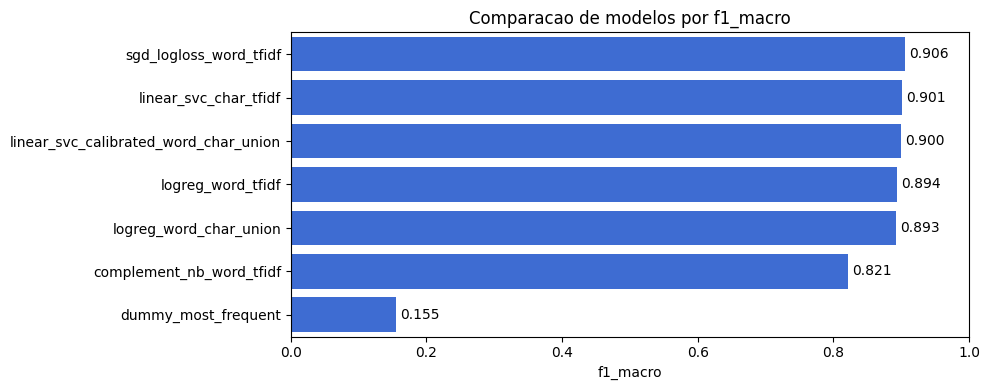

In [10]:
results_path = OUTPUT_DIR / "model_results_holdout.csv"
report_stem = "results_holdout"

classical_models = build_sparse_model_zoo(random_state=experiment_config.random_state)
if results_path.exists() and not FORCE_RETRAIN_CLASSICAL:
    results_df = pd.read_csv(results_path)
    fitted_models = {}
    print("Resultados clássicos carregados de:", results_path)
else:
    results_df, fitted_models = evaluate_model_zoo(
        train_clean,
        models=classical_models,
        config=experiment_config,
    )
    save_results_table(results_df, results_path)
    save_experiment_report(results_df, OUTPUT_DIR, filename_stem=report_stem)
    print("Resultados clássicos recalculados e salvos em:", results_path)

ranked = rank_results(results_df, metric="f1_macro")
display(ranked)
plot_metric_comparison(results_df, metric="f1_macro")


In [11]:
top_model_names = ranked.head(3)["model"].tolist()
cv_results_path = OUTPUT_DIR / "model_results_cv_top3.csv"

if cv_results_path.exists() and not FORCE_RETRAIN_CLASSICAL:
    cv_results = pd.read_csv(cv_results_path)
    print("Validação cruzada carregada de:", cv_results_path)
else:
    cv_results = cross_validate_best_models(
        train_clean,
        model_names=top_model_names,
        models=build_sparse_model_zoo(random_state=experiment_config.random_state),
        config=experiment_config,
    )
    cv_results.to_csv(cv_results_path, index=False)
    print("Validação cruzada salva em:", cv_results_path)

display(cv_results)


Validação cruzada carregada de: /Users/andersongoncalves/Documents/PLN-Final/template-implementacao/outputs/model_results_cv_top3.csv


,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std
0,linear_svc_calibrated_word_char_union,0.924309,0.005466,0.905557,0.007655,0.923449,0.005590
1,sgd_logloss_word_tfidf,0.922153,0.005309,0.904815,0.007925,0.922028,0.005282
2,linear_svc_char_tfidf,0.918773,0.003981,0.903720,0.007503,0.919234,0.003763


In [12]:
if "fitted_models" in globals() and fitted_models:
    best_name, best_holdout_model = select_best_model(results_df, fitted_models, metric="f1_macro")
    print("Melhor modelo clássico nesta execução:", best_name)
    best_info = fitted_models[best_name]
    plot_confusion_matrix(best_info["y_valid"], best_info["y_pred"], labels=sorted(train_clean["Category"].unique()))
    display(classification_report_frame(best_info["classification_report"]))
else:
    best_name = ranked.iloc[0]["model"]
    print("Melhor modelo clássico segundo o cache:", best_name)
    print("Para visualizar matriz de confusão, force FORCE_RETRAIN_CLASSICAL=True e reexecute esta seção.")


Melhor modelo clássico segundo o cache: sgd_logloss_word_tfidf
Para visualizar matriz de confusão, force FORCE_RETRAIN_CLASSICAL=True e reexecute esta seção.


A escolha do modelo de auditoria deve seguir o ranking, não uma preferência fixa. A versão anterior usava `logreg_word_tfidf` por conveniência, mas isso desperdiçava informação quando outro modelo probabilístico tinha desempenho superior. A partir daqui, a auditoria usa o melhor modelo ranqueado que oferece `predict_proba`; se nenhum estiver disponível, usa o melhor modelo geral com aproximação por margem.


---
## 6. Validação robusta e ensemble CSV-only

Esta seção concentra as ideias mais importantes para competir bem usando apenas os CSVs.

Primeiro, geramos probabilidades out-of-fold. Isso significa que cada linha do treino recebe uma probabilidade produzida por um modelo que não viu o rótulo daquela linha. Essas probabilidades permitem otimizar ensemble, prior de duplicata e Viterbi sem vazamento.

Depois, combinamos três fontes de sinal:

1. **Texto**: probabilidades de TF-IDF e, quando disponíveis, probabilidades salvas de LegalBERT/BERTimbau.
2. **Duplicatas**: distribuição suavizada de rótulos para textos idênticos, sempre calculada sem usar a validação como referência.
3. **Sequência por `Id`**: Viterbi/HMM com rótulos de treino fixos e exemplos de validação/teste tratados como desconhecidos.

Os artefatos desta etapa são salvos em `.npy` e `.csv`, pois são caros o suficiente para merecer reaproveitamento.


In [13]:
modeling_cache_path = CACHE_DIR / "train_modeling.csv"
label_issues_path = OUTPUT_DIR / "potential_label_issues.csv"
pseudo_labeled_path = OUTPUT_DIR / "pseudo_labeled_samples.csv"

audit_models = build_sparse_model_zoo(random_state=experiment_config.random_state)
label_audit_model_name = choose_best_probabilistic_model(ranked, audit_models)
print("Modelo usado para auditoria e pseudo-rotulagem:", label_audit_model_name)

if modeling_cache_path.exists() and not FORCE_REBUILD_AUDIT:
    train_modeling = pd.read_csv(modeling_cache_path)
    label_issues = read_cached_csv(label_issues_path)
    if label_issues is None:
        label_issues = pd.DataFrame()
    pseudo_labeled = read_cached_csv(pseudo_labeled_path)
    if pseudo_labeled is None:
        pseudo_labeled = pd.DataFrame()
    print("Conjunto de treino modelado carregado de:", modeling_cache_path)
else:
    label_issues = detect_label_issues_with_cv(
        train_clean,
        audit_models[label_audit_model_name],
        config=experiment_config,
        min_confidence=0.85,
    )
    label_issues.to_csv(label_issues_path, index=False)

    label_audit_model = fit_model_on_full_train(
        train_clean,
        audit_models[label_audit_model_name],
        config=experiment_config,
    )
    pseudo_labeled, pseudo_report = pseudo_label_unlabeled_samples(
        train_unlabeled_clean,
        label_audit_model,
        config=experiment_config,
        min_confidence=0.92,
    )
    pseudo_labeled.to_csv(pseudo_labeled_path, index=False)

    train_modeling = build_training_set_with_pseudo_labels(
        train_clean,
        pseudo_labeled,
        label_issues=label_issues,
        config=experiment_config,
        correction_min_confidence=0.97,
    )
    train_modeling.to_csv(modeling_cache_path, index=False)
    print("Conjunto de treino modelado salvo em:", modeling_cache_path)

summary_audit = pd.DataFrame([
    {
        "rotuladas_originais": len(train_clean),
        "sem_rotulo_disponiveis": len(train_unlabeled_clean),
        "pseudo_rotuladas_usadas": int((train_modeling.get("IsPseudoLabel", pd.Series(dtype=bool)) == True).sum()),
        "possiveis_rotulos_ruidosos": len(label_issues),
        "correcoes_automaticas": int((train_modeling.get("LabelAuditAction", pd.Series(dtype=object)) == "auto_corrected").sum()),
        "total_treino_modelagem": len(train_modeling),
    }
])
display(summary_audit)


Modelo usado para auditoria e pseudo-rotulagem: sgd_logloss_word_tfidf
Conjunto de treino modelado salvo em: /Users/andersongoncalves/Documents/PLN-Final/template-implementacao/outputs/cache/train_modeling.csv


,rotuladas_originais,sem_rotulo_disponiveis,pseudo_rotuladas_usadas,possiveis_rotulos_ruidosos,correcoes_automaticas,total_treino_modelagem
0,20412,2268,1227,87,0,21639


In [14]:
classes = sorted(train_clean["Category"].astype(int).unique())
sota_models = build_sparse_model_zoo(random_state=experiment_config.random_state)
tfidf_model_name = "logreg_word_char_union" if "logreg_word_char_union" in sota_models else top_model_names[0]

oof_tfidf_path = OUTPUT_DIR / "oof_tfidf.npy"
test_tfidf_path = OUTPUT_DIR / "test_tfidf.npy"

if oof_tfidf_path.exists() and test_tfidf_path.exists() and not FORCE_REBUILD_OOF:
    oof_tfidf = np.load(oof_tfidf_path)
    test_tfidf = np.load(test_tfidf_path)
    print("Probabilidades TF-IDF carregadas do cache.")
else:
    print("Gerando probabilidades OOF com:", tfidf_model_name)
    oof_tfidf, test_tfidf = make_oof_probabilities(
        train_clean,
        test_clean,
        sota_models[tfidf_model_name],
        classes=classes,
        config=experiment_config,
        output_oof_path=oof_tfidf_path,
        output_test_path=test_tfidf_path,
    )

oof_probability_sets = {"tfidf": oof_tfidf}
test_probability_sets = {"tfidf": test_tfidf}
for model_key in ["legalbert", "bertimbau"]:
    oof_path = OUTPUT_DIR / f"oof_{model_key}.npy"
    test_path = OUTPUT_DIR / f"test_{model_key}.npy"
    if oof_path.exists() and test_path.exists():
        oof_probs = np.load(oof_path)
        test_probs = np.load(test_path)
        if oof_probs.shape == oof_tfidf.shape and test_probs.shape == test_tfidf.shape:
            oof_probability_sets[model_key] = oof_probs
            test_probability_sets[model_key] = test_probs
            print(f"Incluindo probabilidades {model_key} no ensemble.")

if len(oof_probability_sets) > 1:
    ensemble_result = optimize_ensemble_weights(
        oof_probability_sets,
        train_clean["Category"].astype(int),
        classes=classes,
        step=0.05,
    )
    ensemble_weights = ensemble_result["weights"]
    ensemble_f1 = ensemble_result["f1_macro"]
else:
    ensemble_weights = {next(iter(oof_probability_sets)): 1.0}
    ensemble_f1 = np.nan

ensemble_oof = average_probabilities(oof_probability_sets, weights=ensemble_weights)
ensemble_test = average_probabilities(test_probability_sets, weights=ensemble_weights)
np.save(OUTPUT_DIR / "oof_ensemble.npy", ensemble_oof)
np.save(OUTPUT_DIR / "test_ensemble.npy", ensemble_test)
print("Pesos do ensemble:", ensemble_weights)

duplicate_oof = make_oof_duplicate_prior_probabilities(
    train_clean,
    classes=classes,
    config=experiment_config,
    alpha=1.0,
)
duplicate_test = duplicate_prior_probabilities(
    train_clean,
    test_clean["Body_clean"],
    classes=classes,
    text_col="Body_clean",
    target_col="Category",
    alpha=1.0,
)
duplicate_lambda = optimize_duplicate_lambda(
    ensemble_oof,
    duplicate_oof,
    train_clean["Category"].astype(int),
    classes=classes,
)
final_oof = duplicate_lambda["probabilities"]
final_test_probs = combine_with_duplicate_prior(
    ensemble_test,
    duplicate_test,
    lambda_dup=duplicate_lambda["lambda_dup"],
)
np.save(OUTPUT_DIR / "oof_ensemble_duplicate.npy", final_oof)
np.save(OUTPUT_DIR / "test_ensemble_duplicate.npy", final_test_probs)

transition_lambda = optimize_transition_lambda_oof(
    train_clean,
    final_oof,
    classes=classes,
    config=experiment_config,
)
transition = estimate_transition_matrix(
    train_clean["Category"].astype(int),
    classes=classes,
    ids=train_clean["Id"],
    alpha=1.0,
)
submission_sota = transductive_viterbi_submission(
    train_clean,
    test_clean,
    final_test_probs,
    classes=classes,
    config=experiment_config,
    transition_probs=transition,
    lambda_transition=transition_lambda["lambda_transition"],
    output_path=OUTPUT_DIR / "submission_sota_csv_viterbi.csv",
)

sota_summary = pd.DataFrame([
    {"model": "csv_only_text_ensemble", "f1_macro": ensemble_f1, "accuracy": np.nan, "details": str(ensemble_weights)},
    {"model": "csv_only_ensemble_duplicate", "f1_macro": duplicate_lambda["f1_macro"], "accuracy": np.nan, "details": f"lambda_dup={duplicate_lambda['lambda_dup']}"},
    {"model": "csv_only_viterbi", "f1_macro": transition_lambda["f1_macro"], "accuracy": np.nan, "details": f"lambda_transition={transition_lambda['lambda_transition']}"},
])
sota_summary.to_csv(OUTPUT_DIR / "model_results_csv_only.csv", index=False)
display(sota_summary)
print("Submissão CSV-only com Viterbi salva em:", OUTPUT_DIR / "submission_sota_csv_viterbi.csv")


Gerando probabilidades OOF com: logreg_word_char_union
Pesos do ensemble: {'tfidf': 1.0}


,model,f1_macro,accuracy,details
0,csv_only_text_ensemble,NaN,NaN,{'tfidf': 1.0}
1,csv_only_ensemble_duplicate,0.910893,NaN,lambda_dup=2.0
2,csv_only_viterbi,0.933419,NaN,lambda_transition=0.5


Submissão CSV-only com Viterbi salva em: /Users/andersongoncalves/Documents/PLN-Final/template-implementacao/outputs/submission_sota_csv_viterbi.csv


O ponto essencial desta seção é a separação entre validação e submissão. As probabilidades OOF são usadas para escolher pesos e lambdas. Já as probabilidades do teste são geradas, por padrão, por um modelo refeito em todo o treino rotulado. Assim, a submissão final aproveita o máximo de informação disponível sem usar rótulos do teste.


---
## 7. Modelos densos e Transformers

Os modelos clássicos capturam muito bem padrões lexicais, mas podem perder relações semânticas mais sutis. Por isso, esta seção testa duas alternativas densas:

1. **SentenceTransformers com chunking**: documentos longos são divididos em partes sobrepostas, cada parte é codificada e as embeddings são agregadas.
2. **Legal-BERTimbau**: um Transformer adaptado ao domínio jurídico em português, ajustado por fine-tuning para as categorias do projeto.

O Legal-BERTimbau base é o padrão recomendado para uma RTX 2080 Ti de 12 GB. Ele deve ser o primeiro teste porque combina domínio jurídico e custo próximo ao BERTimbau Base. O Legal-BERTimbau Large fica listado como alternativa mais pesada para execuções com batch menor ou gradient accumulation.


In [15]:
embedding_model_name = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
emb_train_path = CACHE_DIR / "embeddings_train.npy"
emb_test_path = CACHE_DIR / "embeddings_test.npy"
embedding_results_path = OUTPUT_DIR / "model_results_embeddings.csv"

try:
    if emb_train_path.exists() and emb_test_path.exists() and not FORCE_REBUILD_EMBEDDINGS:
        embeddings_train = np.load(emb_train_path)
        embeddings_test = np.load(emb_test_path)
        print("Embeddings carregadas do cache.")
    else:
        embedding_batch_size = max(1, runtime_profile["transformer_batch_size"] * 2)
        embeddings_train = build_chunked_sentence_embedding_matrix(
            train_modeling["Body_clean"],
            model_name=embedding_model_name,
            batch_size=embedding_batch_size,
            device=runtime_profile["device"],
        )
        embeddings_test = build_chunked_sentence_embedding_matrix(
            test_clean["Body_clean"],
            model_name=embedding_model_name,
            batch_size=embedding_batch_size,
            device=runtime_profile["device"],
        )
        np.save(emb_train_path, embeddings_train)
        np.save(emb_test_path, embeddings_test)
        print("Embeddings salvas no cache.")

    if embedding_results_path.exists() and not FORCE_REBUILD_EMBEDDINGS:
        embedding_results = pd.read_csv(embedding_results_path)
    else:
        embedding_results, embedding_models = evaluate_embedding_classifier(
            train_modeling,
            embeddings_train,
            config=experiment_config,
        )
        embedding_results.to_csv(embedding_results_path, index=False)
    display(embedding_results)
except ImportError as exc:
    embedding_results = pd.DataFrame()
    print("Etapa de embeddings ignorada porque faltam dependências:", exc)


/Users/andersongoncalves/Documents/PLN-Final/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 930/930 [03:28<00:00,  4.47it/s]


Embeddings salvas no cache.


,model,accuracy,f1_macro,f1_weighted
1,embedding_linear_svc,0.788355,0.722550,0.790239
0,embedding_logreg,0.709335,0.628956,0.725314


In [16]:
display(transformer_candidate_models())
print("Ambiente detectado para o fine-tuning:")
display(pd.DataFrame([runtime_profile["environment"]]))


,model_id,family,why,max_length
0,rufimelo/Legal-BERTimbau-sts-base-ma-v2,Legal-BERTimbau Base,Portuguese legal-domain BERTimbau adaptation; safest first legal encoder on 12GB GPUs.,512
1,rufimelo/Legal-BERTimbau-sts-large-ma-v3,Legal-BERTimbau Large,Best-effort legal-domain encoder for stronger GPUs; tuned from Legal-BERTimbau large.,512
2,Tropic-AI/moBERTo,moBERTo,ModernBERT-style Portuguese encoder with long-context support; useful as a 2048/4096-token ablation.,8192
3,neuralmind/bert-base-portuguese-cased,BERTimbau,Strong Brazilian Portuguese encoder baseline.,512
4,neuralmind/bert-large-portuguese-cased,BERTimbau Large,Larger Portuguese encoder when GPU memory allows.,512
5,PORTULAN/albertina-ptbr-base,Albertina PT-BR,Open Portuguese DeBERTa-style encoder trained for PT-BR.,512
6,answerdotai/ModernBERT-base,ModernBERT,Efficient long-context encoder; useful for long legal pages.,8192
7,allenai/longformer-base-4096,Longformer,Long-document attention baseline for documents above 512 tokens.,4096


Ambiente detectado para o fine-tuning:


,torch_installed,torch_version,preferred_device,cuda_available,cuda_device_count,mps_available,devices,fp16_recommended,bf16_supported
0,True,2.12.1,mps,False,0,True,"[{'index': 0, 'name': 'Apple Metal Performance Shaders', 'total_memory_gb': None, 'capability': 'mps'}]",False,False


In [ ]:
# Bootstrap local: permite executar esta célula mesmo após reiniciar o kernel.
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd

if "PROJECT_DIR" not in globals():
    PROJECT_DIR = Path.cwd().resolve()
    if (PROJECT_DIR / "template-implementacao" / "scripts").exists():
        PROJECT_DIR = PROJECT_DIR / "template-implementacao"
    if str(PROJECT_DIR) not in sys.path:
        sys.path.insert(0, str(PROJECT_DIR))

from scripts.notebook_support import cached_preprocessed_data, resolve_project_dir
from scripts.preprocessamento import TextPreprocessConfig
from scripts.experimentos import (
    ExperimentConfig,
    auto_runtime_profile,
    build_sparse_model_zoo,
    fine_tune_transformer_classifier,
    generate_submission,
    generate_transformer_submission,
    load_model,
    load_transformer_trainer,
    fit_model_on_full_train,
    save_model,
)

if "DATA_DIR" not in globals():
    DATA_DIR = PROJECT_DIR / "data"
if "OUTPUT_DIR" not in globals():
    OUTPUT_DIR = PROJECT_DIR / "outputs"
if "MODEL_DIR" not in globals():
    MODEL_DIR = PROJECT_DIR / "models"
if "CACHE_DIR" not in globals():
    CACHE_DIR = OUTPUT_DIR / "cache"
for directory in [OUTPUT_DIR, MODEL_DIR, CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
if "preprocess_config" not in globals():
    preprocess_config = TextPreprocessConfig(
        lowercase=True,
        strip_accents=True,
        normalize_legal_refs=True,
        remove_urls_emails=True,
        remove_stopwords=False,
        min_token_len=2,
        keep_digits=False,
    )
if "experiment_config" not in globals():
    experiment_config = ExperimentConfig(
        text_col="Body_clean",
        target_col="Category",
        id_col="Id",
        random_state=42,
        validation_size=0.2,
        cv_folds=5,
        scoring="f1_macro",
        output_dir=str(OUTPUT_DIR),
    )
if "runtime_profile" not in globals():
    runtime_profile = auto_runtime_profile(prefer_transformer=True)
for flag_name in ["FORCE_RETRAIN_TRANSFORMER", "FORCE_RETRAIN_FINAL"]:
    if flag_name not in globals():
        globals()[flag_name] = False

# Esta célula pode ser executada isoladamente após abrir o notebook: ela recarrega
# os dados pré-processados e o treino modelado se as variáveis ainda não existirem.
if "train_clean" not in globals() or "test_clean" not in globals():
    PROJECT_DIR = resolve_project_dir(Path.cwd())
    DATA_DIR = PROJECT_DIR / "data"
    OUTPUT_DIR = PROJECT_DIR / "outputs"
    MODEL_DIR = PROJECT_DIR / "models"
    CACHE_DIR = OUTPUT_DIR / "cache"
    cache_bundle = cached_preprocessed_data(PROJECT_DIR, DATA_DIR, OUTPUT_DIR, preprocess_config, force=False)
    train_clean = cache_bundle["train_clean"]
    test_clean = cache_bundle["test_clean"]

if "train_modeling" not in globals():
    modeling_cache_path = CACHE_DIR / "train_modeling.csv"
    train_modeling = pd.read_csv(modeling_cache_path) if modeling_cache_path.exists() else train_clean.copy()

transformer_eval_dir = MODEL_DIR / "transformer_eval_legalbert"
transformer_submission_path = OUTPUT_DIR / "submission_transformer.csv"
transformer_results_path = OUTPUT_DIR / "model_results_transformer.csv"

try:
    if transformer_results_path.exists() and transformer_submission_path.exists() and not FORCE_RETRAIN_TRANSFORMER:
        transformer_results = pd.read_csv(transformer_results_path)
        submission_transformer = pd.read_csv(transformer_submission_path)
        print("Transformer carregado de artefatos existentes.")
    else:
        trainer = fine_tune_transformer_classifier(
            train_modeling,
            model_name=runtime_profile["recommended_transformer"],
            config=experiment_config,
            num_train_epochs=runtime_profile["transformer_epochs"],
            learning_rate=runtime_profile["transformer_learning_rate"],
            per_device_train_batch_size=runtime_profile["transformer_batch_size"],
            max_length=runtime_profile["transformer_max_length"],
            output_dir=str(transformer_eval_dir),
            use_class_weights=True,
            use_lora=runtime_profile["use_lora"],
            quantization_4bit=runtime_profile["quantization_4bit"],
            device=runtime_profile["device"],
        )
        eval_metrics = trainer.evaluate()
        trainer.save_model(transformer_eval_dir)
        tokenizer = getattr(trainer, "processing_class", None) or getattr(trainer, "tokenizer", None)
        if tokenizer is not None:
            tokenizer.save_pretrained(transformer_eval_dir)

        submission_transformer = generate_transformer_submission(
            trainer,
            test_clean,
            output_path=transformer_submission_path,
            text_col="Body_clean",
            id_col="Id",
            max_length=runtime_profile["transformer_max_length"],
        )
        transformer_results = pd.DataFrame([
            {
                "model": "transformer_legalbert_eval",
                "accuracy": eval_metrics.get("eval_accuracy", np.nan),
                "f1_macro": eval_metrics.get("eval_f1_macro", np.nan),
                "f1_weighted": eval_metrics.get("eval_f1_weighted", np.nan),
                "details": runtime_profile["recommended_transformer"],
            }
        ])
        transformer_results.to_csv(transformer_results_path, index=False)

    display(transformer_results)
    display(submission_transformer.head())
except ImportError as exc:
    transformer_results = pd.DataFrame()
    print("Etapa Transformer ignorada porque faltam dependências:", exc)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6550.36it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: rufimelo/Legal-BERTimbau-sts-base-ma-v2
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Map: 100%|██████████| 4328/4328 [00:03<00:00, 1146.98 examples/s]
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/Users/andersongoncalves/Documents/PLN-Final/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


---
## 8. Comparação final, escolha do modelo e submissão

A última etapa reúne os resultados disponíveis e escolhe o caminho final. A regra de escolha prioriza `f1_macro`, porque essa métrica dá peso semelhante às classes frequentes e raras. `f1_weighted` e `accuracy` aparecem como métricas auxiliares, úteis para entender estabilidade geral, mas não devem sozinhas definir a solução em uma base desbalanceada.

Depois de escolhido o melhor caminho, a célula final garante uma submissão única em `outputs/submission_final.csv`. Quando o modelo escolhido exige treino, ele é refeito com todos os dados de treinamento disponíveis para modelagem (`train_modeling` quando existir; caso contrário, `train_clean`). Esse ponto é essencial: validação serve para escolher, mas a submissão final deve aproveitar o máximo de informação rotulada.


In [ ]:
# Bootstrap local: permite executar esta célula mesmo após reiniciar o kernel.
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd

if "PROJECT_DIR" not in globals():
    PROJECT_DIR = Path.cwd().resolve()
    if (PROJECT_DIR / "template-implementacao" / "scripts").exists():
        PROJECT_DIR = PROJECT_DIR / "template-implementacao"
    if str(PROJECT_DIR) not in sys.path:
        sys.path.insert(0, str(PROJECT_DIR))

from scripts.notebook_support import cached_preprocessed_data, resolve_project_dir
from scripts.preprocessamento import TextPreprocessConfig
from scripts.experimentos import (
    ExperimentConfig,
    auto_runtime_profile,
    build_sparse_model_zoo,
    fine_tune_transformer_classifier,
    generate_submission,
    generate_transformer_submission,
    load_model,
    load_transformer_trainer,
    fit_model_on_full_train,
    save_model,
)

if "DATA_DIR" not in globals():
    DATA_DIR = PROJECT_DIR / "data"
if "OUTPUT_DIR" not in globals():
    OUTPUT_DIR = PROJECT_DIR / "outputs"
if "MODEL_DIR" not in globals():
    MODEL_DIR = PROJECT_DIR / "models"
if "CACHE_DIR" not in globals():
    CACHE_DIR = OUTPUT_DIR / "cache"
for directory in [OUTPUT_DIR, MODEL_DIR, CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
if "preprocess_config" not in globals():
    preprocess_config = TextPreprocessConfig(
        lowercase=True,
        strip_accents=True,
        normalize_legal_refs=True,
        remove_urls_emails=True,
        remove_stopwords=False,
        min_token_len=2,
        keep_digits=False,
    )
if "experiment_config" not in globals():
    experiment_config = ExperimentConfig(
        text_col="Body_clean",
        target_col="Category",
        id_col="Id",
        random_state=42,
        validation_size=0.2,
        cv_folds=5,
        scoring="f1_macro",
        output_dir=str(OUTPUT_DIR),
    )
if "runtime_profile" not in globals():
    runtime_profile = auto_runtime_profile(prefer_transformer=True)
for flag_name in ["FORCE_RETRAIN_TRANSFORMER", "FORCE_RETRAIN_FINAL"]:
    if flag_name not in globals():
        globals()[flag_name] = False
from scripts.analise_resultados import rank_results

# Recarrega artefatos essenciais caso esta seção seja executada isoladamente.
if "train_clean" not in globals() or "test_clean" not in globals():
    PROJECT_DIR = resolve_project_dir(Path.cwd())
    DATA_DIR = PROJECT_DIR / "data"
    OUTPUT_DIR = PROJECT_DIR / "outputs"
    MODEL_DIR = PROJECT_DIR / "models"
    CACHE_DIR = OUTPUT_DIR / "cache"
    cache_bundle = cached_preprocessed_data(PROJECT_DIR, DATA_DIR, OUTPUT_DIR, preprocess_config, force=False)
    train_clean = cache_bundle["train_clean"]
    test_clean = cache_bundle["test_clean"]

if "train_modeling" not in globals():
    modeling_cache_path = CACHE_DIR / "train_modeling.csv"
    train_modeling = pd.read_csv(modeling_cache_path) if modeling_cache_path.exists() else train_clean.copy()

candidate_rows = []

holdout_path = OUTPUT_DIR / "model_results_holdout.csv"
if holdout_path.exists():
    holdout = pd.read_csv(holdout_path)
    best_classical = rank_results(holdout, metric="f1_macro").iloc[0].to_dict()
    candidate_rows.append({
        "family": "classical",
        "model": f"classical:{best_classical['model']}",
        "accuracy": best_classical.get("accuracy", np.nan),
        "f1_macro": best_classical.get("f1_macro", np.nan),
        "f1_weighted": best_classical.get("f1_weighted", np.nan),
        "details": "Melhor modelo clássico no holdout.",
    })

csv_only_path = OUTPUT_DIR / "model_results_csv_only.csv"
if csv_only_path.exists():
    csv_only = pd.read_csv(csv_only_path)
    best_csv = csv_only.sort_values("f1_macro", ascending=False, na_position="last").iloc[0].to_dict()
    candidate_rows.append({
        "family": "csv_only_sequence",
        "model": best_csv["model"],
        "accuracy": best_csv.get("accuracy", np.nan),
        "f1_macro": best_csv.get("f1_macro", np.nan),
        "f1_weighted": np.nan,
        "details": best_csv.get("details", "Ensemble/prior/Viterbi."),
    })

embedding_path = OUTPUT_DIR / "model_results_embeddings.csv"
if embedding_path.exists():
    embedding = pd.read_csv(embedding_path)
    if not embedding.empty:
        best_embedding = embedding.sort_values("f1_macro", ascending=False, na_position="last").iloc[0].to_dict()
        candidate_rows.append({
            "family": "embeddings",
            "model": f"embedding:{best_embedding['model']}",
            "accuracy": best_embedding.get("accuracy", np.nan),
            "f1_macro": best_embedding.get("f1_macro", np.nan),
            "f1_weighted": best_embedding.get("f1_weighted", np.nan),
            "details": "Classificador linear sobre SentenceTransformers com chunking.",
        })

transformer_path = OUTPUT_DIR / "model_results_transformer.csv"
if transformer_path.exists():
    transformer = pd.read_csv(transformer_path)
    if not transformer.empty:
        best_transformer = transformer.sort_values("f1_macro", ascending=False, na_position="last").iloc[0].to_dict()
        candidate_rows.append({
            "family": "transformer",
            "model": "transformer:legalbert",
            "accuracy": best_transformer.get("accuracy", np.nan),
            "f1_macro": best_transformer.get("f1_macro", np.nan),
            "f1_weighted": best_transformer.get("f1_weighted", np.nan),
            "details": best_transformer.get("details", runtime_profile["recommended_transformer"]),
        })

if not candidate_rows:
    raise RuntimeError("Nenhum resultado de modelo foi encontrado. Execute ao menos as seções 5 e 6 antes da comparação final.")

comparison = pd.DataFrame(candidate_rows)
comparison["selection_metric"] = comparison["f1_macro"].fillna(-1)
comparison = comparison.sort_values(["selection_metric", "accuracy"], ascending=False, na_position="last").reset_index(drop=True)
display(comparison.drop(columns=["selection_metric"]))

best_candidate = comparison.iloc[0].to_dict()
print("Modelo escolhido para submissão final:", best_candidate["model"])
print("Justificativa:", best_candidate["details"])

final_submission_path = OUTPUT_DIR / "submission_final.csv"
final_decision_path = OUTPUT_DIR / "final_model_decision.json"

reuse_final_submission = False
if final_submission_path.exists() and final_decision_path.exists() and not FORCE_RETRAIN_FINAL:
    try:
        previous_decision = json.loads(final_decision_path.read_text(encoding="utf-8"))
        reuse_final_submission = previous_decision.get("model") == best_candidate["model"]
    except json.JSONDecodeError:
        reuse_final_submission = False

if reuse_final_submission:
    submission_final = pd.read_csv(final_submission_path)
    print("Submissão final carregada do cache:", final_submission_path)
else:
    if best_candidate["model"] == "csv_only_viterbi" and (OUTPUT_DIR / "submission_sota_csv_viterbi.csv").exists():
        submission_final = pd.read_csv(OUTPUT_DIR / "submission_sota_csv_viterbi.csv")
    elif best_candidate["model"].startswith("classical:"):
        classical_name = best_candidate["model"].split(":", 1)[1]
        final_model_path = MODEL_DIR / f"final_{classical_name}.joblib"
        if final_model_path.exists() and not FORCE_RETRAIN_FINAL:
            final_model = load_model(final_model_path)
        else:
            final_model = fit_model_on_full_train(
                train_modeling,
                build_sparse_model_zoo(random_state=experiment_config.random_state)[classical_name],
                config=experiment_config,
            )
            save_model(final_model, final_model_path)
        submission_final = generate_submission(
            final_model,
            test_clean,
            output_path=final_submission_path,
            text_col="Body_clean",
            id_col="Id",
        )
    elif best_candidate["model"].startswith("embedding:") and (OUTPUT_DIR / "submission_embeddings.csv").exists():
        submission_final = pd.read_csv(OUTPUT_DIR / "submission_embeddings.csv")
    elif best_candidate["model"].startswith("transformer:"):
        final_transformer_dir = MODEL_DIR / "transformer_final_full_train"
        if final_transformer_dir.exists() and not FORCE_RETRAIN_FINAL:
            final_trainer = load_transformer_trainer(final_transformer_dir, device=runtime_profile["device"])
        else:
            final_trainer = fine_tune_transformer_classifier(
                train_modeling,
                model_name=runtime_profile["recommended_transformer"],
                config=experiment_config,
                num_train_epochs=runtime_profile["transformer_epochs"],
                learning_rate=runtime_profile["transformer_learning_rate"],
                per_device_train_batch_size=runtime_profile["transformer_batch_size"],
                max_length=runtime_profile["transformer_max_length"],
                output_dir=str(final_transformer_dir),
                use_class_weights=True,
                use_lora=runtime_profile["use_lora"],
                quantization_4bit=runtime_profile["quantization_4bit"],
                device=runtime_profile["device"],
                validation_size=0.0,
            )
            final_trainer.save_model(final_transformer_dir)
            tokenizer = getattr(final_trainer, "processing_class", None) or getattr(final_trainer, "tokenizer", None)
            if tokenizer is not None:
                tokenizer.save_pretrained(final_transformer_dir)
        submission_final = generate_transformer_submission(
            final_trainer,
            test_clean,
            output_path=final_submission_path,
            text_col="Body_clean",
            id_col="Id",
            max_length=runtime_profile["transformer_max_length"],
        )
    else:
        raise RuntimeError(f"Não há regra de submissão final para {best_candidate['model']}.")

    submission_final.to_csv(final_submission_path, index=False)
    final_decision_path.write_text(json.dumps(best_candidate, ensure_ascii=False, indent=2), encoding="utf-8")
    print("Submissão final salva em:", final_submission_path)

print("Linhas na submissão final:", len(submission_final))
display(submission_final.head())


---
## Considerações finais

A solução final deve ser interpretada em camadas. Os modelos clássicos oferecem uma base forte e barata, especialmente porque o vocabulário jurídico contém muitos padrões discriminativos. O ensemble CSV-only adiciona duas fontes de informação que não violam a regra do problema: repetição textual e continuidade por `Id`. Os Transformers entram como uma alternativa de maior capacidade, especialmente útil quando o texto exige compreensão contextual além de termos explícitos.

A comparação final não deve ser lida como uma verdade absoluta sobre o problema. Ela resume os resultados obtidos nas validações disponíveis. A confirmação definitiva depende de uma validação justa, sem vazamento por duplicatas, e do desempenho no leaderboard oficial. Por isso, o notebook salva os artefatos intermediários: eles permitem repetir, auditar e comparar cada decisão sem reexecutar todo o pipeline do zero.


---
## Seção extra: Best effort RTX 5000 32 GB

Esta seção é um experimento deliberadamente separado do pipeline principal. A ideia é aproveitar uma GPU mais forte, como a RTX 5000 Ada de 32 GB, para testar um modelo que não precisa obedecer ao perfil conservador usado nas seções anteriores.

A escolha padrão é `rufimelo/Legal-BERTimbau-sts-large-ma-v3`. A justificativa é prática e empírica: ele parte do BERTimbau Large, foi adaptado ao domínio jurídico em português e possui aproximadamente 0,3 bilhão de parâmetros. Para esta tarefa, isso é mais promissor do que trocar apenas para um encoder genérico maior, porque o vocabulário e as fórmulas processuais importam muito. A literatura recente em classificação jurídica brasileira também reforça que fine-tuning de modelos especializados pode superar LLMs genéricos em tarefas discriminativas. Como alternativa experimental, `Tropic-AI/moBERTo` fica documentado no código por ser um ModernBERT português de contexto longo; ele é interessante para ablações futuras com 2.048 ou 4.096 tokens, mas o caminho padrão privilegia domínio jurídico e estabilidade.

O segundo componente é sequencial. O artigo sobre VICTOR/STF mostra que as páginas/documentos de um processo formam sequências e que modelar transições melhora a classificação. Como só temos CSV, usamos uma aproximação ética: o Transformer produz probabilidades para o teste, e um Viterbi/HMM usa apenas a ordem por `Id` e os rótulos conhecidos do treino como posições fixas. Nenhum rótulo do teste é usado.

A célula abaixo pode ser executada sozinha depois de reiniciar o kernel. Ela recarrega os CSVs pré-processados quando existirem, reconstrói o cache se necessário, treina um modelo de validação para registrar métricas e depois treina o modelo final com todos os dados disponíveis para gerar `outputs/submission_best_effort.csv`.


In [ ]:
# Experimento best effort independente para RTX 5000 Ada 32 GB.
from pathlib import Path
import json
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-cache")

import numpy as np
import pandas as pd

PROJECT_DIR = Path.cwd().resolve()
if (PROJECT_DIR / "template-implementacao" / "scripts").exists():
    PROJECT_DIR = PROJECT_DIR / "template-implementacao"
elif not (PROJECT_DIR / "scripts").exists():
    for candidate in [PROJECT_DIR, *PROJECT_DIR.parents]:
        if (candidate / "scripts").exists() and (candidate / "data").exists():
            PROJECT_DIR = candidate
            break
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from scripts.notebook_support import cached_preprocessed_data, resolve_project_dir
from scripts.preprocessamento import TextPreprocessConfig
from scripts.experimentos import (
    ExperimentConfig,
    auto_runtime_profile,
    estimate_transition_matrix,
    fine_tune_transformer_classifier,
    load_transformer_trainer,
    predict_transformer_probabilities,
    transductive_viterbi_submission,
)

PROJECT_DIR = resolve_project_dir(PROJECT_DIR)
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
MODEL_DIR = PROJECT_DIR / "models"
CACHE_DIR = OUTPUT_DIR / "cache"
for directory in [OUTPUT_DIR, MODEL_DIR, CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

preprocess_config = TextPreprocessConfig(
    lowercase=True,
    strip_accents=True,
    normalize_legal_refs=True,
    remove_urls_emails=True,
    remove_stopwords=False,
    min_token_len=2,
    keep_digits=False,
)
experiment_config = ExperimentConfig(
    text_col="Body_clean",
    target_col="Category",
    id_col="Id",
    random_state=42,
    validation_size=0.2,
    cv_folds=5,
    scoring="f1_macro",
    output_dir=str(OUTPUT_DIR),
)
runtime_profile = auto_runtime_profile(prefer_transformer=True)

BEST_EFFORT_MODEL_ID = "rufimelo/Legal-BERTimbau-sts-large-ma-v3"
BEST_EFFORT_LONG_CONTEXT_ALT = "Tropic-AI/moBERTo"  # ablação opcional; comece com max_length 2048/4096.
BEST_EFFORT_MAX_LENGTH = 512
BEST_EFFORT_EPOCHS = 5
BEST_EFFORT_LEARNING_RATE = 1e-5
BEST_EFFORT_WEIGHT_DECAY = 0.01
BEST_EFFORT_WARMUP_RATIO = 0.06
BEST_EFFORT_VALIDATION_SIZE = 0.15
BEST_EFFORT_BATCH_SIZE = 8 if runtime_profile["device"] == "cuda" else 1
BEST_EFFORT_GRADIENT_ACCUMULATION = 2 if runtime_profile["device"] == "cuda" else 1
BEST_EFFORT_VITERBI_LAMBDA = 0.75
BEST_EFFORT_RUN_VALIDATION = True
BEST_EFFORT_FORCE_RETRAIN_EVAL = False
BEST_EFFORT_FORCE_RETRAIN_FINAL = False
BEST_EFFORT_FORCE_REPREDICT = False

best_effort_tag = "legalbert_large"
best_effort_eval_dir = MODEL_DIR / f"best_effort_eval_{best_effort_tag}"
best_effort_final_dir = MODEL_DIR / f"best_effort_final_{best_effort_tag}"
best_effort_results_path = OUTPUT_DIR / "model_results_best_effort.csv"
best_effort_raw_submission_path = OUTPUT_DIR / "submission_best_effort_transformer.csv"
best_effort_viterbi_submission_path = OUTPUT_DIR / "submission_best_effort_viterbi.csv"
best_effort_submission_path = OUTPUT_DIR / "submission_best_effort.csv"
best_effort_metadata_path = OUTPUT_DIR / "best_effort_metadata.json"

cache_bundle = cached_preprocessed_data(
    project_dir=PROJECT_DIR,
    data_dir=DATA_DIR,
    output_dir=OUTPUT_DIR,
    config=preprocess_config,
    force=False,
)
train_clean = cache_bundle["train_clean"].copy()
test_clean = cache_bundle["test_clean"].copy()

modeling_cache_path = CACHE_DIR / "train_modeling.csv"
if modeling_cache_path.exists():
    train_best = pd.read_csv(modeling_cache_path)
    training_source = str(modeling_cache_path)
else:
    train_best = train_clean.copy()
    training_source = "train_clean rotulado"
train_best[experiment_config.target_col] = train_best[experiment_config.target_col].astype(int)
best_effort_classes = sorted(train_best[experiment_config.target_col].astype(int).unique())

print("Projeto:", PROJECT_DIR)
print("Dispositivo detectado:", runtime_profile["device"])
print("Modelo best effort:", BEST_EFFORT_MODEL_ID)
print("Fonte de treino:", training_source)
print("Batch efetivo:", BEST_EFFORT_BATCH_SIZE * BEST_EFFORT_GRADIENT_ACCUMULATION)

if runtime_profile["device"] != "cuda":
    print("Atenção: esta seção foi calibrada para CUDA/RTX 5000. Em CPU ela deve funcionar, mas será muito lenta.")

if (
    best_effort_results_path.exists()
    and best_effort_submission_path.exists()
    and best_effort_raw_submission_path.exists()
    and not BEST_EFFORT_FORCE_RETRAIN_EVAL
    and not BEST_EFFORT_FORCE_RETRAIN_FINAL
    and not BEST_EFFORT_FORCE_REPREDICT
):
    best_effort_results = pd.read_csv(best_effort_results_path)
    best_effort_raw_submission = pd.read_csv(best_effort_raw_submission_path)
    best_effort_submission = pd.read_csv(best_effort_submission_path)
    print("Artefatos best effort carregados do cache.")
else:
    if BEST_EFFORT_RUN_VALIDATION:
        if best_effort_results_path.exists() and best_effort_eval_dir.exists() and not BEST_EFFORT_FORCE_RETRAIN_EVAL:
            best_effort_results = pd.read_csv(best_effort_results_path)
            print("Métricas best effort carregadas de:", best_effort_results_path)
        else:
            eval_trainer = fine_tune_transformer_classifier(
                train_best,
                model_name=BEST_EFFORT_MODEL_ID,
                config=experiment_config,
                num_train_epochs=BEST_EFFORT_EPOCHS,
                learning_rate=BEST_EFFORT_LEARNING_RATE,
                per_device_train_batch_size=BEST_EFFORT_BATCH_SIZE,
                gradient_accumulation_steps=BEST_EFFORT_GRADIENT_ACCUMULATION,
                max_length=BEST_EFFORT_MAX_LENGTH,
                output_dir=str(best_effort_eval_dir),
                weight_decay=BEST_EFFORT_WEIGHT_DECAY,
                warmup_ratio=BEST_EFFORT_WARMUP_RATIO,
                gradient_checkpointing=True,
                use_class_weights=True,
                device=runtime_profile["device"],
                validation_size=BEST_EFFORT_VALIDATION_SIZE,
            )
            eval_metrics = eval_trainer.evaluate()
            eval_trainer.save_model(best_effort_eval_dir)
            eval_tokenizer = getattr(eval_trainer, "processing_class", None) or getattr(eval_trainer, "tokenizer", None)
            if eval_tokenizer is not None:
                eval_tokenizer.save_pretrained(best_effort_eval_dir)
            best_effort_results = pd.DataFrame([
                {
                    "model": "best_effort_legalbert_large_eval",
                    "accuracy": eval_metrics.get("eval_accuracy", np.nan),
                    "f1_macro": eval_metrics.get("eval_f1_macro", np.nan),
                    "f1_weighted": eval_metrics.get("eval_f1_weighted", np.nan),
                    "details": BEST_EFFORT_MODEL_ID,
                    "max_length": BEST_EFFORT_MAX_LENGTH,
                    "epochs": BEST_EFFORT_EPOCHS,
                    "effective_batch_size": BEST_EFFORT_BATCH_SIZE * BEST_EFFORT_GRADIENT_ACCUMULATION,
                }
            ])
            best_effort_results.to_csv(best_effort_results_path, index=False)
    else:
        best_effort_results = pd.DataFrame([
            {
                "model": "best_effort_legalbert_large_eval_skipped",
                "accuracy": np.nan,
                "f1_macro": np.nan,
                "f1_weighted": np.nan,
                "details": "Validação ignorada por BEST_EFFORT_RUN_VALIDATION=False.",
                "max_length": BEST_EFFORT_MAX_LENGTH,
                "epochs": BEST_EFFORT_EPOCHS,
                "effective_batch_size": BEST_EFFORT_BATCH_SIZE * BEST_EFFORT_GRADIENT_ACCUMULATION,
            }
        ])
        best_effort_results.to_csv(best_effort_results_path, index=False)

    if best_effort_final_dir.exists() and not BEST_EFFORT_FORCE_RETRAIN_FINAL:
        final_trainer = load_transformer_trainer(best_effort_final_dir, device=runtime_profile["device"])
        print("Modelo final best effort carregado de:", best_effort_final_dir)
    else:
        final_trainer = fine_tune_transformer_classifier(
            train_best,
            model_name=BEST_EFFORT_MODEL_ID,
            config=experiment_config,
            num_train_epochs=BEST_EFFORT_EPOCHS,
            learning_rate=BEST_EFFORT_LEARNING_RATE,
            per_device_train_batch_size=BEST_EFFORT_BATCH_SIZE,
            gradient_accumulation_steps=BEST_EFFORT_GRADIENT_ACCUMULATION,
            max_length=BEST_EFFORT_MAX_LENGTH,
            output_dir=str(best_effort_final_dir),
            weight_decay=BEST_EFFORT_WEIGHT_DECAY,
            warmup_ratio=BEST_EFFORT_WARMUP_RATIO,
            gradient_checkpointing=True,
            use_class_weights=True,
            device=runtime_profile["device"],
            validation_size=0.0,
        )
        final_trainer.save_model(best_effort_final_dir)
        final_tokenizer = getattr(final_trainer, "processing_class", None) or getattr(final_trainer, "tokenizer", None)
        if final_tokenizer is not None:
            final_tokenizer.save_pretrained(best_effort_final_dir)
        print("Modelo final best effort treinado com todos os dados e salvo em:", best_effort_final_dir)

    best_effort_probs, best_effort_label_values = predict_transformer_probabilities(
        final_trainer,
        test_clean,
        text_col="Body_clean",
        max_length=BEST_EFFORT_MAX_LENGTH,
    )
    best_effort_label_values = [int(label) for label in best_effort_label_values]
    aligned_probs = np.zeros((len(test_clean), len(best_effort_classes)), dtype=float)
    class_to_col = {label: idx for idx, label in enumerate(best_effort_classes)}
    for source_idx, label in enumerate(best_effort_label_values):
        target_idx = class_to_col.get(label)
        if target_idx is not None:
            aligned_probs[:, target_idx] = best_effort_probs[:, source_idx]
    row_sums = aligned_probs.sum(axis=1, keepdims=True)
    aligned_probs = np.divide(
        aligned_probs,
        np.maximum(row_sums, 1e-12),
        out=np.full_like(aligned_probs, 1.0 / len(best_effort_classes)),
        where=row_sums > 0,
    )

    raw_labels = np.asarray(best_effort_classes, dtype=int)[np.argmax(aligned_probs, axis=1)]
    best_effort_raw_submission = pd.DataFrame({"Id": test_clean["Id"].values, "Category": raw_labels.astype(int)})
    best_effort_raw_submission.to_csv(best_effort_raw_submission_path, index=False)

    transition = estimate_transition_matrix(
        train_best[experiment_config.target_col].astype(int),
        classes=best_effort_classes,
        ids=train_best[experiment_config.id_col],
        alpha=1.0,
    )
    best_effort_submission = transductive_viterbi_submission(
        train_best,
        test_clean,
        aligned_probs,
        classes=best_effort_classes,
        config=experiment_config,
        transition_probs=transition,
        lambda_transition=BEST_EFFORT_VITERBI_LAMBDA,
        output_path=best_effort_viterbi_submission_path,
    )
    best_effort_submission.to_csv(best_effort_submission_path, index=False)

    metadata = {
        "model_id": BEST_EFFORT_MODEL_ID,
        "long_context_alternative": BEST_EFFORT_LONG_CONTEXT_ALT,
        "training_source": training_source,
        "final_training_uses_validation": False,
        "max_length": BEST_EFFORT_MAX_LENGTH,
        "epochs": BEST_EFFORT_EPOCHS,
        "learning_rate": BEST_EFFORT_LEARNING_RATE,
        "warmup_ratio": BEST_EFFORT_WARMUP_RATIO,
        "batch_size": BEST_EFFORT_BATCH_SIZE,
        "gradient_accumulation_steps": BEST_EFFORT_GRADIENT_ACCUMULATION,
        "effective_batch_size": BEST_EFFORT_BATCH_SIZE * BEST_EFFORT_GRADIENT_ACCUMULATION,
        "viterbi_lambda": BEST_EFFORT_VITERBI_LAMBDA,
        "outputs": {
            "raw_transformer": str(best_effort_raw_submission_path),
            "viterbi": str(best_effort_viterbi_submission_path),
            "final": str(best_effort_submission_path),
        },
        "references": [
            "https://huggingface.co/rufimelo/Legal-BERTimbau-sts-large-ma-v3",
            "https://arxiv.org/abs/2207.00748",
            "https://arxiv.org/abs/2604.18878",
            "https://arxiv.org/abs/2606.22722",
        ],
    }
    best_effort_metadata_path.write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")

print("Resultados best effort:")
display(best_effort_results)
print("Submissão raw Transformer:", best_effort_raw_submission_path)
print("Submissão final com Viterbi:", best_effort_submission_path)
print("Linhas na submissão final:", len(best_effort_submission))
display(best_effort_submission.head())
